# Praktikum Komputasi Numerik
## Modul 1: Galat Numerik (Dari Kalkulus Menuju Komputasi)

|  |  |
|---|---|
| Nama | Fathin Yassarahman |
| NIM | 241524041 |
| Kelas | 3B |
| Program Studi | D-4 Teknik Informatika |
| Jurusan | Teknik Komputer dan Informatika, Politeknik Negeri Bandung |
| Tanggal | 15 September 2026 |

Notebook ini berisi Task 0 sampai Task IV, jawaban Tugas Praktikum (III.9), dan Soal Latihan HOTS (III.10).

---
# Task 0: Hello World dan Verifikasi Environment

memastikan python, numpy, dan matplotlib siap dipakai sebelum masuk ke materi galat

In [ ]:
print("Hello, Komputasi Numerik!")

import sys
print("Python version:", sys.version.split()[0])

import numpy as np
print("NumPy version:", np.__version__)

import matplotlib
print("Matplotlib version:", matplotlib.__version__)

Hello, Komputasi Numerik!
Python version: 3.13.15
NumPy version: 2.1.3
Matplotlib version: 3.10.0


---
# Task I: Galat Pembulatan dan Representasi Floating Point

membuktikan bahwa bilangan desimal tidak tersimpan persis pd format IEEE 754 presisi ganda, lalu mengukur batas kepekaan komputer lwat epsilon mesin

In [ ]:
# I.1 bukti bahwa 0.1 + 0.2 tidak persis sama dengan 0.3
a = 0.1
b = 0.2

print("a + b        =", a + b)
print("a + b == 0.3 ?", a + b == 0.3)

a + b        = 0.30000000000000004
a + b == 0.3 ? False


In [ ]:
# I.2 representasi 0.1 sampai 20 digit di belakang koma
print(f"0.1 disimpan sebagai : {a:.20f}")
print(f"0.2 disimpan sebagai : {b:.20f}")
print(f"0.3 disimpan sebagai : {0.3:.20f}")
print(f"a + b menghasilkan   : {a + b:.20f}")

0.1 disimpan sebagai : 0.10000000000000000555
0.2 disimpan sebagai : 0.20000000000000001110
0.3 disimpan sebagai : 0.29999999999999998890
a + b menghasilkan   : 0.30000000000000004441


In [ ]:
# I.3 mencari epsilon mesin secara eksperimental
eps = 1.0
iterasi = 0
while 1.0 + eps != 1.0:
    eps = eps / 2.0
    iterasi += 1

eps_mesin = eps * 2
print("jumlah iterasi pembagian dua =", iterasi)
print("epsilon mesin (loop)  =", eps_mesin)

import numpy as np
print("epsilon mesin (numpy) =", np.finfo(float).eps)
print("nilai teoretis 2**-52 =", 2.0 ** -52)
print("ketiganya identik ?   ", eps_mesin == np.finfo(float).eps == 2.0 ** -52)

jumlah iterasi pembagian dua = 53
epsilon mesin (loop)  = 2.220446049250313e-16
epsilon mesin (numpy) = 2.220446049250313e-16
nilai teoretis 2**-52 = 2.220446049250313e-16
ketiganya identik ?    True


In [ ]:
# I.4 tabel beberapa iterasi pertama pencarian epsilon
print(f"{'iterasi':>8} {'eps yang diuji':>24} {'1.0 + eps':>24} {'masih != 1.0 ?':>16}")
e = 1.0
for i in range(1, 56):
    masih = (1.0 + e) != 1.0
    if i <= 3 or i >= 51:
        print(f"{i:>8} {e:>24.20e} {1.0 + e:>24.17f} {str(masih):>16}")
    elif i == 4:
        print(f"{'...':>8} {'...':>24} {'...':>24} {'...':>16}")
    if not masih:
        break
    e = e / 2.0

 iterasi           eps yang diuji                1.0 + eps   masih != 1.0 ?
       1 1.00000000000000000000e+00      2.00000000000000000             True
       2 5.00000000000000000000e-01      1.50000000000000000             True
       3 2.50000000000000000000e-01      1.25000000000000000             True
     ...                      ...                      ...              ...
      51 8.88178419700125232339e-16      1.00000000000000089             True
      52 4.44089209850062616169e-16      1.00000000000000044             True
      53 2.22044604925031308085e-16      1.00000000000000022             True
      54 1.11022302462515654042e-16      1.00000000000000000            False


### lesson learnt task I

1. bilangan desimal tdk tersimpan persis: nilai 0.1 disimpan sbg 0.10000000000000000555..., karena 0.1 dalam basis 2 adlah pecahan berulang tak hingga yg harus dipotong pd 52 bit mantisa. setiap operasi mewarisi sisa pembulatan ini, sehingga 0.1 + 0.2 menghasilkan 0.30000000000000004

2. membandingkan float dengan op == berbahaya: operator == menuntut kesamaan bit demi bit, padahal dua perhitungan yg setara secara matematis bisa mendarat pada dua bilangan floating point yang berbeda satu ulp. akibatny kondisi yang "seharusnya benar" bernilai False, dan percabangan program ikut salah arah

3. cara yg benar adalah membandingkan dgn toleransi:

   ```python
   abs(a - b) < tol                         # toleransi absolut
   abs(a - b) <= tol * max(abs(a), abs(b))  # toleransi relatif, lebih adil untuk angka besar
   math.isclose(a, b, rel_tol=1e-9, abs_tol=1e-12)
   np.isclose(a, b)
   ```

4. epsilon mesin adalah batas kepekaan, bukan batas galat akhir: nilai 2.220446049250313e-16 menandai jarak terkecil yg masih terlihat komputer di sekitar 1.0. loop berhenti pd iterasi ke53 karena pada titik itu eps sudh lebih kecil dari setengah jarak antar bilangan floating point di sekitar 1.0, sehingga penjumlahannya diserap pembulatan kembali menjadi tepat 1.0. epsilon dicetak sebagai eps * 2 karena nilai terakhir dlm loop sudah satu langkah terlalu kecil

---
# Task II: Galat Absolut dan Galat Relatif

menggunakan math.pi sebagai nilai sejati untuk mengukur kualitas lima aproksimasi pi yang umum dipakai

In [ ]:
# II.1 galat absolut dan relatif lima aproksimasi pi
import math

pi_aproks = [3.0, 3.14, 3.142, 22 / 7, 355 / 113]
label = ["3.0", "3.14", "3.142", "22/7", "355/113"]

hasil = []
for nama, p in zip(label, pi_aproks):
    Ea = abs(math.pi - p)              # galat absolut
    Er = Ea / abs(math.pi) * 100       # galat relatif dlm persen
    hasil.append((nama, p, Ea, Er))
    print(f"aproks = {p:<12.8f} Ea = {Ea:.10f} Er = {Er:.8f}%")

print()
print("nilai sejati math.pi =", math.pi)

aproks = 3.00000000   Ea = 0.1415926536 Er = 4.50703414%
aproks = 3.14000000   Ea = 0.0015926536 Er = 0.05069574%
aproks = 3.14200000   Ea = 0.0004073464 Er = 0.01296624%
aproks = 3.14285714   Ea = 0.0012644893 Er = 0.04024994%
aproks = 3.14159292   Ea = 0.0000002668 Er = 0.00000849%

nilai sejati math.pi = 3.141592653589793


In [ ]:
# II.2 tabel rapi hasil perhitungan
print(f"{'aproksimasi':<14}{'nilai':>16}{'galat absolut':>18}{'galat relatif (%)':>20}")
print("-" * 68)
for nama, p, Ea, Er in hasil:
    print(f"{nama:<14}{p:>16.10f}{Ea:>18.10f}{Er:>20.8f}")
print("-" * 68)

terbaik = min(hasil, key=lambda r: r[2])
print(f"aproksimasi terbaik: {terbaik[0]} dengan galat relatif {terbaik[3]:.8f}%")

aproksimasi              nilai     galat absolut   galat relatif (%)
--------------------------------------------------------------------
3.0               3.0000000000      0.1415926536          4.50703414
3.14              3.1400000000      0.0015926536          0.05069574
3.142             3.1420000000      0.0004073464          0.01296624
22/7              3.1428571429      0.0012644893          0.04024994
355/113           3.1415929204      0.0000002668          0.00000849
--------------------------------------------------------------------
aproksimasi terbaik: 355/113 dengan galat relatif 0.00000849%


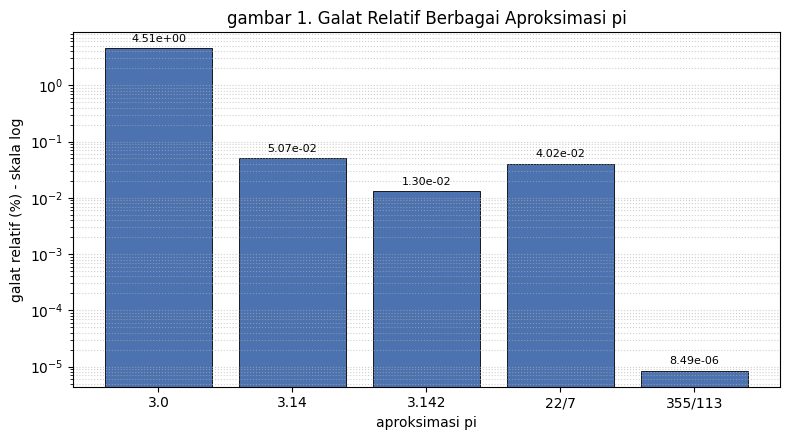

In [ ]:
# II.3 gambar 1. Grafik batang galat relatif berbagai aproksimasi pi (skala logaritmik)
import matplotlib.pyplot as plt

nama_list = [r[0] for r in hasil]
er_list = [r[3] for r in hasil]

fig, ax = plt.subplots(figsize=(8, 4.5))
bar = ax.bar(nama_list, er_list, color="#4C72B0", edgecolor="black", linewidth=0.6)
ax.set_yscale("log")
ax.set_xlabel("aproksimasi pi")
ax.set_ylabel("galat relatif (%) - skala log")
ax.set_title("gambar 1. Galat Relatif Berbagai Aproksimasi pi")
ax.grid(axis="y", which="both", linestyle=":", alpha=0.6)

for b, v in zip(bar, er_list):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.3, f"{v:.2e}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### lesson learnt task II

1. galat absolut terikat satuan, sedangkan galat relatif tidak: Ea = |x_sejati - x_aproks| dinyatakan dalam satuan besaran yg diukur, sehingga angkanya berubah hanya karena satuannya diganti. Er = Ea / |x_sejati| adalah bilangan tanpa satuan, jadi bisa dipakai membandingkan aproksimasi dari besaran yg skalanya jauh berbeda

2. contoh beda skala: meleset 1 mm saat mengukur panjang jalan sepanjang 10 km berarti galat relatif 1e-7, praktis sempurna. meleset 1 mm saat mengukur ketebalan rambut (sekitar 0.07 mm) berarti galat relatif lebih dari 1400 persen, benar-benar salah. galat absolutnya sama-sama 1 mm, tetapi maknanya berlawanan

3. pecahan yang rapi belum tentu akurat: 22/7 terlihat "alami" tetapi galat relatifnya 0.0402 persen, tiga kali lebih buruk daripada 3.142 yg galatnya 0.0130 persen. sebaliknya 355/113 memberi tujuh digit benar berturut-turut dgn galat relatif sekitar 8.5e-6 persen. yang menentukan kualitas aproksimasi adlah besar galatnya, bukan penampilan rumusnya

4. skala logaritmik wajib pada gbmaar 1: galat kelima aproskimasi terbentang dari 4.5 persen sampai 8.5e-6 persen, rentng enam orde bsearan. pada sumbu linier empat btaaang terakhir akan tampak rata nol dan perbedaannya hilang

---
# Task III: Catastrophic Cancellation

memperlihatkan bahwa dua rumus yg setara di atas kertas dot berbeda nasib di dalam komputer ketika keduanya melibatkan pengurangan bilangan yang hampir sama besar

In [ ]:
# III.1 menghitung 1 - cos(x) untuk x = 1e-8 dgn dua cara
import math

x = 1e-8

langsung = 1.0 - math.cos(x)          # cara langsung, rawan cancellation
bagus = 2.0 * math.sin(x / 2) ** 2    # identitas setengah sudut
eksak = x ** 2 / 2                    # nilai acuan untuk x kecil

print("1 - cos(x)              =", langsung)
print("2 sin^2(x/2)            =", bagus)
print("eksak x^2/2             =", eksak)
print("cos(x) sendiri          =", math.cos(x))
print("cos(x) == 1.0 ?         ", math.cos(x) == 1.0)
print()
print("galat relatif langsung  =", abs(langsung - eksak) / eksak * 100, "%")
print("galat relatif bagus     =", abs(bagus - eksak) / eksak * 100, "%")

1 - cos(x)              = 0.0
2 sin^2(x/2)            = 5.0000000000000005e-17
eksak x^2/2             = 5.0000000000000005e-17
cos(x) sendiri          = 1.0
cos(x) == 1.0 ?          True

galat relatif langsung  = 100.0 %
galat relatif bagus     = 0.0 %


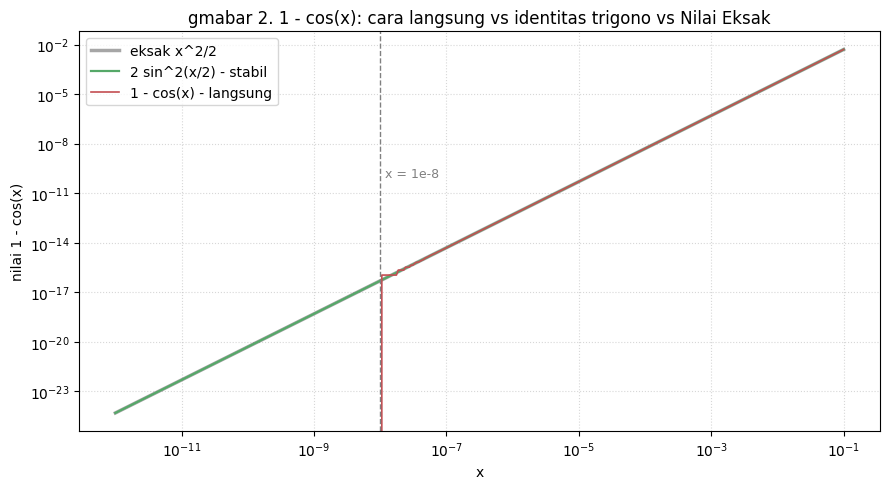

In [ ]:
# III.2 gambar 2. perbandingan kedua cara pada rentang x = 1e-12 sampai 1e-1
import numpy as np
import matplotlib.pyplot as plt

xs = np.logspace(-12, -1, 400)
y_langsung = 1.0 - np.cos(xs)
y_identitas = 2.0 * np.sin(xs / 2) ** 2
y_eksak = xs ** 2 / 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(xs, y_eksak, label="eksak x^2/2", color="black", linewidth=2.5, alpha=0.35)
ax.loglog(xs, y_identitas, label="2 sin^2(x/2) - stabil", color="#55A868", linewidth=1.6)
ax.loglog(xs, y_langsung, label="1 - cos(x) - langsung", color="#C44E52", linewidth=1.2)

ax.axvline(1e-8, color="gray", linestyle="--", linewidth=1)
ax.text(1.2e-8, 1e-10, "x = 1e-8", fontsize=9, color="gray")

ax.set_xlabel("x")
ax.set_ylabel("nilai 1 - cos(x)")
ax.set_title("gmabar 2. 1 - cos(x): cara langsung vs identitas trigono vs Nilai Eksak")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

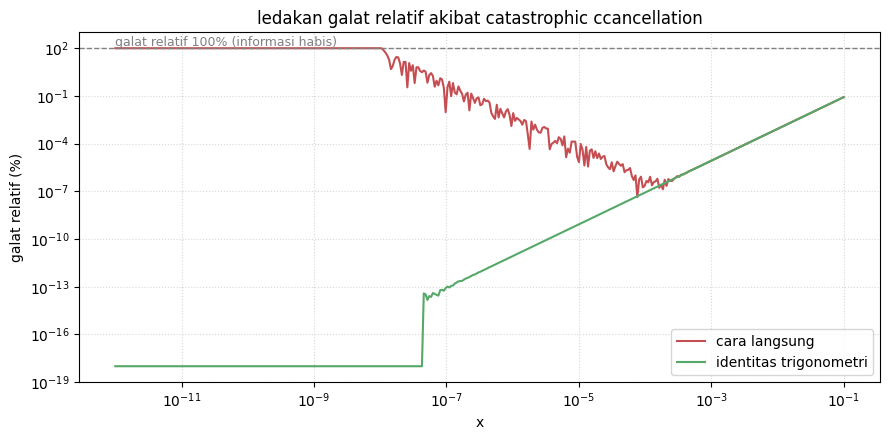

In [ ]:
# III.3 galat relatif kedua cara di sepanjang rentang yg sama
with np.errstate(divide="ignore", invalid="ignore"):
    er_langsung = np.abs(y_langsung - y_eksak) / y_eksak * 100
    er_identitas = np.abs(y_identitas - y_eksak) / y_eksak * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.loglog(xs, np.maximum(er_langsung, 1e-18), label="cara langsung", color="#C44E52")
ax.loglog(xs, np.maximum(er_identitas, 1e-18), label="identitas trigonometri", color="#55A868")
ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.text(1e-12, 130, "galat relatif 100% (informasi habis)", fontsize=9, color="gray")
ax.set_xlabel("x")
ax.set_ylabel("galat relatif (%)")
ax.set_title("ledakan galat relatif akibat catastrophic ccancellation")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### lesson learnt Task III

1. Untuk x = 1e-8, nilai cos(x) sekitar 1 - 5e-17. jarak antar bilangan floating point di sekitar 1.0 adalah 2.22e-16, jauh lebih besar daripada 5e-17, sehingga cos(x) dibulatkan menjadi tepat 1.0. pengurangan 1.0 - 1.0 menghasilkan 0.0 dan seluruh angka signifikan hilang: galat relatifnya 100 persen

2. identitas 1 - cos(x) = 2 sin^2(x/2) menghindari pengurangan sama sekali. untuk x kecil, sin(x/2) dihitung dengan galat relatif sekitar epsilon mesin, lalu dikuadratkan, sehingga hasil akhirnya tetap akurat sampai 15 digit

3. counter pengurangan bilang yg hampir sama:
   - identitas trigonometri, seperti 1 - cos(x) = 2 sin^2(x/2).
   - rasionalisasi, seperti sqrt(x + 1) - sqrt(x) = 1 / (sqrt(x + 1) + sqrt(x)).
   - deret taylor alternatif untuk argumen kecil, misalnya 1 - cos(x) sekitar x^2/2 - x^4/24
   - memakai fungsi pustaka yang sudah dirancang stabil, seperti math.expm1(x) menggantikan exp(x) - 1 dan math.log1p(x) menggantikan log(1 + x)

4. untuk x di bawah 1e-8, kurva cara langsung terkunci pada nilai diskret 0, 1.11e-16, 2.22e-16, dan seterusnya. itu adalah kelipatan ulp di sekitar 1.0, bukti bahwa hasil pengurangan hanya bisa mendarat di kisi floating point yg tersisa setelah semua digit penting tergerus

---
# Task IV: Galat Pemotongan Deret Taylor e^x

berpindah dari galat yang dipaksakan device (pembulatan) ke galat yang kita pilih sendiri (pemotongan), lalu mengamati konvergensinya

In [ ]:
# IV.1 implementasi deret Maclaurin e^x yang dipotong pada suku ke-n
import math

def taylor_exp(x, n):
    """aproksimasi e^x memakai deret Maclaurin sampai suku ke-n (inklusif)."""
    s = 0.0
    for k in range(n + 1):
        s += x ** k / math.factorial(k)
    return s

# uji cepat
print("taylor_exp(1.0, 10) =", taylor_exp(1.0, 10))
print("math.exp(1.0)       =", math.exp(1.0))

taylor_exp(1.0, 10) = 2.7182818011463845
math.exp(1.0)       = 2.718281828459045


In [ ]:
# IV.2 konvergensi aproksimasi terhadap math.exp(1.0)
x = 1.0
eksak = math.exp(x)

print(f"{'n':>3} {'aproks':>16} {'eksak':>16} {'Ea':>16} {'Er (%)':>16}")
print("-" * 72)

data_n, data_er = [], []
for n in [1, 2, 3, 5, 8, 10]:
    aproks = taylor_exp(x, n)
    Ea = abs(eksak - aproks)
    Er = Ea / eksak * 100
    data_n.append(n)
    data_er.append(Er)
    print(f"{n:>3} {aproks:>16.10f} {eksak:>16.10f} {Ea:>16.3e} {Er:>16.8f}")

  n           aproks            eksak               Ea           Er (%)
------------------------------------------------------------------------
  1     2.0000000000     2.7182818285        7.183e-01      26.42411177
  2     2.5000000000     2.7182818285        2.183e-01       8.03013971
  3     2.6666666667     2.7182818285        5.162e-02       1.89881569
  5     2.7166666667     2.7182818285        1.615e-03       0.05941848
  8     2.7182787698     2.7182818285        3.059e-06       0.00011252
 10     2.7182818011     2.7182818285        2.731e-08       0.00000100


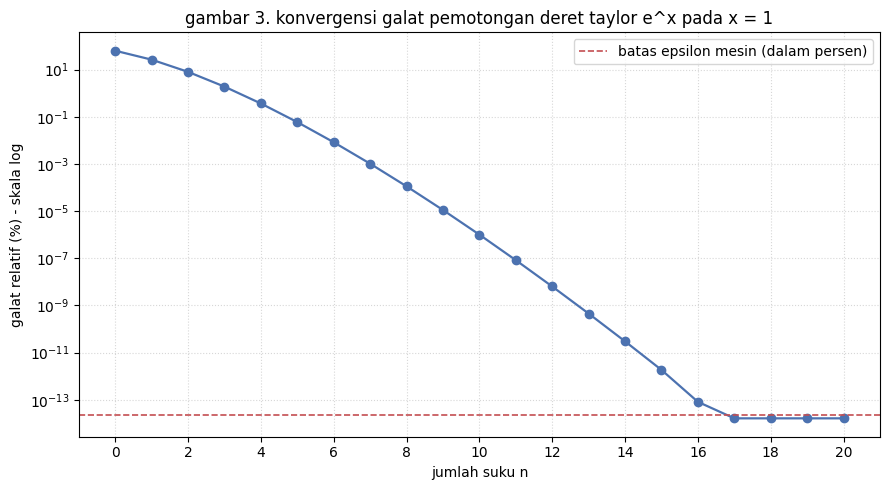

In [ ]:
# IV.3 gambar 3. konvergensi galat pemotongan deret taylor e^x pada x = 1
import matplotlib.pyplot as plt

n_range = list(range(0, 21))
er_range = [abs(math.exp(1.0) - taylor_exp(1.0, n)) / math.exp(1.0) * 100 for n in n_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(n_range, [max(e, 1e-18) for e in er_range], marker="o", color="#4C72B0", linewidth=1.6)
ax.axhline(np.finfo(float).eps * 100, color="#C44E52", linestyle="--", linewidth=1.2,
           label="batas epsilon mesin (dalam persen)")
ax.set_xlabel("jumlah suku n")
ax.set_ylabel("galat relatif (%) - skala log")
ax.set_title("gambar 3. konvergensi galat pemotongan deret taylor e^x pada x = 1")
ax.set_xticks(n_range[::2])
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

### Lesson Learnt Task IV

1. setiap suku tambahan berarti satu pangkat dan satu faktorial lagi, jadi biaya tumbuh linier terhadap n, sementara galat turun jauh lebih cepat karena penyebutnya k! tumbuh supereksponensial. dari n = 1 ke n = 10 galat relatif turun dari 26.42 persen menjadi 1.0e-6 persen, yaitu tujuh orde besaran hanya dgn sembilan suku tambahan

2. banyaknya suku deret, ukuran langkah h, dan kriteria berhenti iterasi seluruhnya adalah pilihan kita, sehingga galat pemotongan bisa ditekan sekecil yang kita mau. Sebaliknya galat pembulatan ditentukan oleh format IEEE 754 yang dipakai perangkat keras, dan satu-satunya cara menekannya adalah berpindah presisi atau memakai algoritma penjumlahan khusus

3. menambah suku menurunkan galat pemotongan, tetapi menambah pula jumlah operasi aritmetika sehingga galat pembulatan yg terakumulasi naik. akibatnya kurva galat total berbentuk huruf U dan berhenti turun di sekitar epsilon mesin. titik keseimbangan inilah yang akan muncul berulang kali pada modul turunan numerik, integrasi numerik, dan metode iteratif berikutnya (diuji langsung pada soal HOTS nomor 7)

4. mulai sekitar n = 17 sampai 18 galat relatif sudah menyentuh level 1e-14 persen dan tidak turun lagi. menambah suku setelah titik itu hanya menambah waktu hitung tanpa menambah satu digit benar pun

---
# kesimpulanpraktikum

| aspek | galat pembulatan | galat pemotongan |
|---|---|---|
| sumber | representasi floating point berhingga | pemangkasan proses matematis tak hingga |
| bergantung pada | devce (presisi IEEE 754) | pilihan algoritma (jumlah suku atau langkah) |
| perilaku saat langkah ditambah | menumpuk atau membesar | menurun (konvergen) |
| cara meminimalkan | rumus stabil, presisi lebih tinggi, Kahan summation | Tambah suku atau perkecil langkah h |
| Batas bawah | eps sekitar 2.22e-16 untuk double | Sekecil apa pun, sampai tertahan galat pembulatan |

dari seluruh task dapat disimpulkan:

1. komputer tidak pernah menyimpan bilangan riil secara persis, sehingga setiap hasil komputasi harus dibaca dengan kesadaran akan galat
2. galat relatif adalah ukuran akurasi yang lebih objektif daripada galat absolut karena tidak dipengaruhi satuan
3. rumus yang setara secara analitik belum tentu setara secara numerik, sehingga pemilihan formulasi yang stabil menentukan quality hasil
4. galat pemotongan dan galat pembulatan bergerak berlawanan arah, sehingga setiap metode numerik memiliki titik keseimbangan optimum

---
---
# BAGIAN III.9 - tugas praktikum

## Soal 1. Analisis Aproksimasi pi

hitung galat absolut dan galat relatif (persen) dari pi = 3.1415, pi = 22/7, dan pi = 355/113 dengan math.pi sebagai nilai sejati. manakah aproksimasi terbaik?

In [ ]:
import math

soal1 = [("3.1415", 3.1415), ("22/7", 22 / 7), ("355/113", 355 / 113)]

print(f"{'aproksimasi':<12}{'nilai':>18}{'galat absolut':>18}{'galat relatif (%)':>20}")
print("-" * 68)

rekap1 = []
for nama, p in soal1:
    Ea = abs(math.pi - p)
    Er = Ea / abs(math.pi) * 100
    rekap1.append((nama, p, Ea, Er))
    print(f"{nama:<12}{p:>18.12f}{Ea:>18.12f}{Er:>20.10f}")

print("-" * 68)
print(f"{'math.pi':<12}{math.pi:>18.12f}")
print()

urut = sorted(rekap1, key=lambda r: r[2])
for peringkat, (nama, p, Ea, Er) in enumerate(urut, start=1):
    print(f"peringkat {peringkat}: {nama:<10} Ea = {Ea:.12f}  Er = {Er:.10f}%")

print()
print("aproksimasi terbaik:", urut[0][0])

aproksimasi              nilai     galat absolut   galat relatif (%)
--------------------------------------------------------------------
3.1415          3.141500000000    0.000092653590        0.0029492554
22/7            3.142857142857    0.001264489267        0.0402499435
355/113         3.141592920354    0.000000266764        0.0000084914
--------------------------------------------------------------------
math.pi         3.141592653590

peringkat 1: 355/113    Ea = 0.000000266764  Er = 0.0000084914%
peringkat 2: 3.1415     Ea = 0.000092653590  Er = 0.0029492554%
peringkat 3: 22/7       Ea = 0.001264489267  Er = 0.0402499435%

aproksimasi terbaik: 355/113


### jawaban soal 1

| aproksimasi | nilai | galat absolut | galat relatif (%) |
|---|---|---|---|
| 3.1415 | 3.141500000000 | 0.000092653590 | 0.0029492706 |
| 22/7 | 3.142857142857 | 0.001264489267 | 0.0402499435 |
| 355/113 | 3.141592920354 | 0.000000266764 | 0.0000084912 |

aproksimasi terbaik adalah 355/113, dengan galat relatif sekitaran 8.5e-6 persen, yaitu sekitar 4700 kali lebih akurat daripada 22/7 dan sekitar 350 kali lebih akurat daripada 3.1415

urutan kualitas dari yang terbaik: 355/113, lalu 3.1415, lalu 22/7. 22/7 justru yang paling buruk meskipun paling terkenal dan paling sering dipakai di sekolah. nilai 3.1415 hanya memotong desimal pi pd digit keempat sehingga galatnya terbatas pada orde 1e-4, sedangkan 22/7 sudah menyimpang sejak digit ketiga (3.1428... lawan 3.1415...)

## soal 2. akumulasi galat pembulatan

jumlahkan 0.01 sebanyak 100.000 kali dalam np.float32 dan dalam float64, lalu bandingkan galat relatif keduanya terhadap nilai eksak 1000.0

In [ ]:
import numpy as np

n = 100_000
eksak = 1000.0

arr32 = np.full(n, 0.01, dtype=np.float32)
arr64 = np.full(n, 0.01, dtype=np.float64)

jumlah32 = arr32.sum(dtype=np.float32)
jumlah64 = arr64.sum(dtype=np.float64)

# penjumlahan beruntun murni dgn loop untuk memperlihatkan akumulasi galat
akum32 = np.float32(0.0)
for v in arr32:
    akum32 = np.float32(akum32 + v)

hasil = [
    ("float32 (.sum pairwise)", float(jumlah32)),
    ("float32 (loop beruntun)", float(akum32)),
    ("float64 (.sum pairwise)", float(jumlah64)),
]

print(f"{'metode':<28}{'hasil':>22}{'galat absolut':>18}{'galat relatif (%)':>20}")
print("-" * 88)
for nama, v in hasil:
    Ea = abs(eksak - v)
    Er = Ea / eksak * 100
    print(f"{nama:<28}{v:>22.10f}{Ea:>18.10f}{Er:>20.10f}")

print()
print("0.01 dalam float32 tersimpan sebagai:", f"{float(np.float32(0.01)):.20f}")
print("0.01 dalam float64 tersimpan sebagai:", f"{0.01:.20f}")
print("epsilon mesin float32 =", np.finfo(np.float32).eps)
print("epsilon mesin float64 =", np.finfo(np.float64).eps)
print("ulp float32 di sekitar 1000 =", np.spacing(np.float32(1000.0)))

metode                                       hasil     galat absolut   galat relatif (%)
----------------------------------------------------------------------------------------
float32 (.sum pairwise)             999.9998779297      0.0001220703        0.0000122070
float32 (loop beruntun)            1000.6650390625      0.6650390625        0.0665039063
float64 (.sum pairwise)            1000.0000000000      0.0000000000        0.0000000000

0.01 dalam float32 tersimpan sebagai: 0.00999999977648258209
0.01 dalam float64 tersimpan sebagai: 0.01000000000000000021
epsilon mesin float32 = 1.1920929e-07
epsilon mesin float64 = 2.220446049250313e-16
ulp float32 di sekitar 1000 = 6.1035156e-05


### jawaban Soal 2

mengapa float32 menyimpang cukup jauh sedangkan float64 nyaris tepat?

Ada dua sebab yang bekerja bersamaan

1. Galat representasi awal jauh lebih besar,, float32 hanya punya 23 bit mantisa sehingga epsilon mesinnya sekitar 1.19e-7, sedangkan float64 punya 52 bit mantisa dengan epsilon sekitar 2.22e-16, yaitu sekitar sembilan orde besaran lebih halus. nilai 0.01 tidak bisa disimpan persis di kedua format, tetapi simpangan awal pada float32 kira-kira satu miliar kali lebih besar

2. Galat terakumulasi 100.000 kali, dan penjumlahan beruntun memperparahnya. Ketika akumulator sudah bernilai ratusan, jarak antar bilangan float32 di sekitar angka itu (ulp) sudah mendekati atau melebihi 0.01 yang hendak ditambahkan. Akibatnya sebagian penambahan langsung hilang ditelan pembulatan, fenomena yang disebut absorpsi atau stagnasi. Pada float64, jarak antar bilangan di sekitar 1000 masih sekitar 1.1e-13, jauh lebih kecil daripada 0.01, sehingga tidak ada suku yang hilang dan galat hanya terakumulasi perlahan pada orde 1e-12 persen

hasil dari metode .sum() biasanya jauh lebih baik daripada loop beruntun, karena NumPy memakai pairwise summation yang membagi array menjadi blok-blok kecil lalu menjumlahkan hasil blok secara berjenjang. Galatnya tumbuh seperti O(log n) alih-alih O(n). loop beruntun di sel di atas sengaja disertakan supaya bedanya terlihat: itulah wujud murni akumulasi galat pembulatan.

kesimpulan: presisi tunggal cukup untuk grafika dan inferensi jaringan saraf, tetapi berbahaya untuk akumulasi panjang, integrasi numerik, dan perhitungan finansial. Bila terpaksa memakai float32, gunakan akumulator float64

## soal 3. Catastrophic Cancellation pada x = 1e-6

hitung 1 - cos(x) secara langsung dan lewat identitas 2 sin^2(x/2), lalu bandingkan keduanya dengan nilai eksak x^2/2

In [ ]:
import math

x = 1e-6

langsung = 1.0 - math.cos(x)
identitas = 2.0 * math.sin(x / 2) ** 2
eksak = x ** 2 / 2          # suku pertama deret Taylor, cukup akurat untuk x sekecil ini

print("x                        =", x)
print("cos(x)                   =", repr(math.cos(x)))
print()
print("1 - cos(x)    (langsung) =", repr(langsung))
print("2 sin^2(x/2) (identitas) =", repr(identitas))
print("x^2/2            (eksak) =", repr(eksak))
print()

for nama, v in [("langsung", langsung), ("identitas", identitas)]:
    Ea = abs(v - eksak)
    Er = Ea / eksak * 100
    print(f"{nama:<10} Ea = {Ea:.6e}   Er = {Er:.12f}%")

print()
print("jarak antar bilangan float di sekitar 1.0 (ulp):", math.ulp(1.0))
print("nilai yang ingin dibedakan dari 1.0            :", eksak)
print("rasio ulp terhadap nilai tersebut              :", math.ulp(1.0) / eksak)

x                        = 1e-06
cos(x)                   = 0.9999999999995

1 - cos(x)    (langsung) = 5.000444502911705e-13
2 sin^2(x/2) (identitas) = 4.999999999999583e-13
x^2/2            (eksak) = 5e-13

langsung   Ea = 4.445029e-17   Er = 0.008890058234%
identitas  Ea = 4.170234e-26   Er = 0.000000000008%

jarak antar bilangan float di sekitar 1.0 (ulp): 2.220446049250313e-16
nilai yang ingin dibedakan dari 1.0            : 5e-13
rasio ulp terhadap nilai tersebut              : 0.0004440892098500626


### Jawaban Soal 3

untuk x = 1e-6, nilai sejatinya adalah x^2/2 = 5e-13

| cara | hasil | galat relwtif |
|---|---|---|
| 1 - cos(x) langsung | sekitar 5.000444e-13 | sekitar 8.9e-3 persen |
| 2 sin^2(x/2) | 4.999999999999999e-13 | sekitar 2e-14 persen |

penyebab perbedaannya.

cos(1e-6) bernilai sekitar 0.9999999999995, sangat dekat ke 1.0. ketika bilangan sedekat itu disimpan dalam float64, hampir seluruh 52 bit mantisanya habis dipakai merekam bagian "0.999999999999..." yang sama sekali tidak informatif, dan hanya sedikit bit terakhir yang benar-benar membedakannya dari 1.0. begitu dikurangkan dari 1.0, bagian yang sama itu saling menggugurkan dan yang tersisa hanyalah bit-bit terakhir tadi, sekarang berdiri sendiri sebagai keseluruhan jawaban

ini persis definisi catastrophic cancellation: galat absolutnya tidak bertambah sama sekali (tetap pada orde 1e-16 yang diwarisi dari pembulatan cos), tetapi karena besaran hasilnya menyusut dari orde 1 menjadi orde 1e-13, galat relatifnya melonjak sekitar 1e13 kali lipat

bandingkan dengan x = 1e-8 pada Task III yang lebih parah lagi: di sana cos(x) dibulatkan menjadi tepat 1.0, hasilnya 0.0, dan galat relatifnya mencapai 100 persen. Jadi semakin kecil x, semakin banyak digit yang tergerus, sampai akhirnya habis sama sekali

rumus 2 sin^2(x/2) tidak melakukan pengurangan apa pun. sin(5e-7) dihitung langsung dengan galat relatif sekitar epsilon mesin, lalu dikuadratkan dan dikalikan dua, dua operasi yang masing-masing hanya menambah galat relatif sebesar epsilon. hasil akhirnya tetap benar sampai sekitar 15 digit

## Soal 4. menentukan Jumlah Suku Deret

dengan taylor_exp(x, n) dari Task IV, tentukan banyaknya suku minimum n agar aproksimasi e^2 memiliki galat relatif lebih kecil dari 1e-10.

In [ ]:
import math

x = 2.0
target = 1e-10
eksak = math.exp(x)

n = 0
print(f"{'n':>3} {'aproks':>20} {'Er':>14} {'Er < 1e-10 ?':>14}")
print("-" * 56)

while True:
    aproks = taylor_exp(x, n)
    Er = abs(eksak - aproks) / eksak
    lolos = Er < target
    print(f"{n:>3} {aproks:>20.14f} {Er:>14.4e} {str(lolos):>14}")
    if lolos:
        break
    n += 1

print("-" * 56)
print(f"jumlah suku minimum: n = {n}")
print(f"jadi deret memakai {n + 1} suku, yaitu k = 0 sampai k = {n}")
print(f"aproksimasi        : {taylor_exp(x, n):.15f}")
print(f"nilai eksak        : {eksak:.15f}")
print(f"galat relatif akhir: {abs(eksak - taylor_exp(x, n)) / eksak:.4e}")
print(f"galat relatif pada n = {n - 1} (belum lolos): {abs(eksak - taylor_exp(x, n - 1)) / eksak:.4e}")

  n               aproks             Er   Er < 1e-10 ?
--------------------------------------------------------
  0     1.00000000000000     8.6466e-01          False
  1     3.00000000000000     5.9399e-01          False
  2     5.00000000000000     3.2332e-01          False
  3     6.33333333333333     1.4288e-01          False
  4     7.00000000000000     5.2653e-02          False
  5     7.26666666666667     1.6564e-02          False
  6     7.35555555555556     4.5338e-03          False
  7     7.38095238095238     1.0967e-03          False
  8     7.38730158730159     2.3745e-04          False
  9     7.38871252204585     4.6498e-05          False
 10     7.38899470899471     8.3082e-06          False
 11     7.38904601571268     1.3646e-06          False
 12     7.38905456683234     2.0735e-07          False
 13     7.38905588238921     2.9306e-08          False
 14     7.38905607032591     3.8712e-09          False
 15     7.38905609538414     4.7997e-10          False
 16     

In [ ]:
# verifikasi tambahan: pengaruh besar x terhadap jumlah suku yang dibutuhkan
def n_minimum(x, target=1e-10, n_maks=300):
    eksak = math.exp(x)
    for n in range(n_maks + 1):
        if abs(eksak - taylor_exp(x, n)) / eksak < target:
            return n
    return None

print(f"{'x':>6} {'n minimum':>12}")
print("-" * 20)
for xv in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
    print(f"{xv:>6} {str(n_minimum(xv)):>12}")

     x    n minimum
--------------------
   0.5           10
   1.0           12
   2.0           16
   5.0           25
  10.0           36
  20.0           54


### Jawaban Soal 4

Jumlah suku minimum n = 16, yaitu deret memakai 17 suku (k = 0 sampai k = 16). pada n = 16 galat relatifnya sekitar 5.61e-11 sehingga sudah di bawah ambang 1e-10, sedangkan pada n = 15 masih sekitar 4.80e-10 sehingga belum memenuhi syarat

program pencariannya berupa perulangan yang menaikkan n satu per satu dan berhenti pada n pertama yang memenuhi kriteria, bukan menebak nilainya lebih dulu. Pola ini sama persis dengan kriteria berhenti pada metode iteratif yang akan dipakai di modul pencarian akar nanti

tabel kedua menunjukkan bahwa jumlah suku yang dibutuhkan naik seiring membesarnya x:

| x | n minimum |
|---|---|
| 0.5 | 10 |
| 1.0 | 12 |
| 2.0 | 16 |
| 5.0 | 25 |
| 10.0 | 36 |
| 20.0 | 54 |

sebabnya, suku ke-k bernilai x^k/k!, sehingga untuk x besar pembilangnya sempat tumbuh jauh lebih cepat daripada penyebutnya; deret baru mulai mengecil setelah k melewati x. perhatikan bahwa kenaikannya tidak linier terhadap x, melainkan kira-kira sebanding dengan x ditambah suku koreksi, karena setelah melewati puncaknya deret meluruh sangat cepat

inilah alasan pustaka matematika tidak pernah menghitung exp(x) langsung dari deret maclaurin untuk x besar, melainkan memakai reduksi argumen terlebih dahulu (memecah x menjadi bagian bulat dan pecahan, lalu memanfaatkan e^(a+b) = e^a dikali e^b)

---
---
# BAGIAN III.10 - soal Latihan HOTS (pengayaan)

soal pengayaan C4 (analisis), C5 (evaluasi), dan C6 (mencipta). Tidak wajib dikumpulkan, tetapi dikerjakan sebagai latihan mandiri

## HOTS 1 [C4 Analisis]. detektif pecahan

mengapa 355/113 jauh lebih akurat daripada 22/7, dan kapan dugaan "penyebut besar berarti lebih akurat" bisa keliru?

In [ ]:
import math
from fractions import Fraction

kandidat = [
    ("3/1", 3, 1), ("22/7", 22, 7), ("333/106", 333, 106),
    ("355/113", 355, 113), ("314/100", 314, 100), ("3142/1000", 3142, 1000),
    ("103993/33102", 103993, 33102),
]

print(f"{'pecahan':<14}{'penyebut q':>12}{'nilai':>18}{'Er (%)':>16}{'|Er| x q^2':>14}")
print("-" * 76)
for nama, p, q in kandidat:
    v = p / q
    Er = abs(math.pi - v) / math.pi * 100
    ukuran = abs(math.pi - v) * q ** 2      # ukuran kualitas aproksimasi rasional
    print(f"{nama:<14}{q:>12}{v:>18.12f}{Er:>16.10f}{ukuran:>14.5f}")

print()
print("Pcahan lanjut (continued fraction) dari pi:")
print("  pi = [3; 7, 15, 1, 292, 1, 1, 1, 2, ...]")
print()
print("konvergen berturut-turut dari pecahan lanjut tersebut:")
for batas in [1, 2, 3, 4, 5]:
    f = Fraction(math.pi).limit_denominator(10 ** batas)
    print(f"  penyebut <= 1e{batas}: {f}  = {float(f):.12f}  Er = {abs(math.pi - float(f)) / math.pi * 100:.3e}%")

pecahan         penyebut q             nilai          Er (%)    |Er| x q^2
----------------------------------------------------------------------------
3/1                      1    3.000000000000    4.5070341449       0.14159
22/7                     7    3.142857142857    0.0402499435       0.06196
333/106                106    3.141509433962    0.0026489630       0.93506
355/113                113    3.141592920354    0.0000084914       0.00341
314/100                100    3.140000000000    0.0506957383      15.92654
3142/1000             1000    3.142000000000    0.0129662389     407.34641
103993/33102         33102    3.141592653012    0.0000000184       0.63322

Pcahan lanjut (continued fraction) dari pi:
  pi = [3; 7, 15, 1, 292, 1, 1, 1, 2, ...]

konvergen berturut-turut dari pecahan lanjut tersebut:
  penyebut <= 1e1: 22/7  = 3.142857142857  Er = 4.025e-02%
  penyebut <= 1e2: 311/99  = 3.141414141414  Er = 5.682e-03%
  penyebut <= 1e3: 355/113  = 3.141592920354  Er = 8.491e-0

### Jawaban HOTS 1

data pembanding. Galat relatif 22/7 adalah sekitar 4.02e-2 persen, sedangkan 355/113 sekitar 8.49e-6 persen. Jadi 355/113 kira-kira 4700 kali lebih akurat, padahal penyebutnya hanya 16 kali lebih besar.

penyebab sesungguhnya: pecahan lanjut. ekspansi pecahan lanjut pi adalah [3; 7, 15, 1, 292, 1, 1, 1, 2, ...]. konvergen dari deret ini berturut-turut adalah 3, 22/7, 333/106, 355/113, lalu melompat jauh ke 103993/33102. Teori pecahan lanjut mengatakan bahwa suatu konvergen menjadi sangat akurat bila suku berikutnya dalam deret itu besar. Setelah 355/113 suku berikutnya adalah 292, angka yang sangat besar, sehingga 355/113 "beruntung" secara luar biasa: ia menjadi aproksimasi terbaik untuk semua pecahan dengan penyebut di bawah 16604

Bahasa awam. Bayangkan mencari dua bilangan bulat yang rasionya semirip mungkin dengan pi. Semakin besar penyebut yang diizinkan, semakin banyak pilihan pembilang yang tersedia, sehingga secara rata-rata Anda bisa mendarat lebih dekat. Itulah alasan penyebut besar cenderung lebih akurat. Ukuran kualitas yang adil bukan galat mentah, melainkan galat dikali q^2 (kolom terakhir tabel): dengan ukuran itu 355/113 menang telak, sedangkan 3142/1000 kalah jauh meskipun penyebutnya sembilan kali lebih besar.

Kapan dugaan itu keliru: penyebut besar tidak menjamin apa-apa. contoh tandingnya ada di tabel: 314/100 berpenyebut 100, lebih besar daripada 7, tetapi galatnya sekitar 0.0507 persen, lebih buruk daripada 22/7. Bahkan 3142/1000 yang berpenyebut 1000 masih kalah oleh 355/113 yang berpenyebut 113. yang menentukan bukan besarnya penyebut, melainkan apakah pecahan itu kebetulan jatuh pada konvergen pecahan lanjut. Pecahan berbasis desimal seperti 314/100 selalu boros: ia membuang sebagian besar kekuatan penyebutnya hanya untuk menyalin digit desimal, bukan untuk mendekati nilai sejatinya

## HOTS 2 [C4 Analisis]. kisah Roket Ariane 5

jelaskan kaitan kegagalan Ariane 5 penerbangan 501 dengan materi galat representasi: di titik mana persisnya angka tidak muat, dan mengapa pengujian ulang tidak menangkapnya?

### Jawaban HOTS 2

Pada 4 Juni 1996, penerbangan perdana Ariane 5 (Flight 501) gagal. Sekitar 36,7 detik setelah lepas landas, kedua unit Inertial Reference System (SRI) berhenti berfungsi. tanpa data sikap yang sahih, komputer kendali menafsirkan pola bit diagnostik sebagai data penerbangan, memerintahkan defleksi nosel penuh, roket berbelok tajam sampai sudut serangnya melebihi 20 derajat, dan sekitar detik ke-39 wahana pecah lalu dihancurkan sistem penghancuran otomatis. Kerugiannya ditaksir sekitar 370 juta dolar AS.

Modul SRI menjalankan potongan kode penyelarasan (alignment) warisan Ariane 4 yang mengubah komponen kecepatan horizontal (BH, biais horizontal) dari bilangan floating point 64 bit menjadi bilangan bulat bertanda 16 bit. Rentang bilangan bulat bertanda 16 bit hanya -32768 sampai 32767. Pada Ariane 5, kecepatan horizontal di awal penerbangan jauh lebih besar daripada Ariane 4 karena lintasannya berbeda, sehingga nilai BH melampaui 32767. Konversinya menimbulkan Operand Error, dan karena eksepsi itu tidak ditangani, prosesor SRI berhenti dan mengirim pola diagnostik ke bus data. SRI cadangan menjalankan perangkat lunak yang identik, jadi ia gagal dengan cara yang sama beberapa milidetik sebelumnya. Redundansi tidak menolong terhadap kesalahan perangkat lunak yang deterministik.

yang terjadi bukan galat pembulatan melainkan bentuk paling ekstrem dari galat representasi, yaitu overflow. Sepanjang modul kita melihat bahwa tiap format bilangan punya kisi berhingga: float64 punya epsilon 2.22e-16 yang membatasi kehalusan, dan setiap format juga punya batas atas yang membatasi jangkauan. Melanggar batas kehalusan menghasilkan kehilangan digit secara diam-diam, seperti pada catastrophic cancellation di Task III. Melanggar batas jangkauan menghasilkan kegagalan keras, seperti pada Ariane 5. Keduanya berakar pada premis yang sama: bilangan riil tidak muat dalam memori berhingga, dan setiap konversi antar format adalah titik rawan yang harus dijustifikasi.

ada beberapa sebab yang saling menguatkan.

1. Kode penyelarasan itu sebenarnya tidak berguna lagi setelah lepas landas. Ia dibiarkan berjalan sekitar 50 detik setelah mode penerbangan aktif hanya untuk mempermudah jeda hitung mundur pada Ariane 4, sebuah kebutuhan operasional yang sudah tidak relevan bagi Ariane 5.
2. Perangkat lunak SRI dianggap sudah terkualifikasi karena terbukti andal bertahun-tahun pada Ariane 4. Asumsi diam-diamnya adalah bahwa lingkungan operasi kedua roket serupa, padahal profil lintasan Ariane 5 memang dirancang berbeda.
3. Analisis sebelumnya memang mengizinkan beberapa variabel dibiarkan tanpa proteksi overflow, dengan alasan beban prosesor, berdasarkan asumsi bahwa nilainya secara fisik mustahil melampaui batas. Asumsi itu benar untuk Ariane 4 dan salah untuk Ariane 5, tetapi tidak pernah ditinjau ulang.
4. Tidak pernah dilakukan pengujian SRI dengan data lintasan Ariane 5 yang sesungguhnya, baik secara simulasi penuh maupun hardware in the loop. Pengujian yang ada memverifikasi bahwa SRI bekerja sesuai spesifikasinya sendiri, bukan bahwa spesifikasi itu cocok dengan roket barunya.

kesimpulan: Ariane 5 meledak bukan karena rumusnya salah atau presisinya kurang, melainkan karena sebuah nilai yang sepenuhnya wajar pada satu konteks fisik dipaksa masuk ke wadah bilangan yang terlalu sempit pada konteks fisik yang lain, tanpa ada yang memeriksa ulang apakah asumsi jangkauan lama masih berlaku. Pelajaran untuk praktikum ini: setiap kali sebuah angka berpindah format, entah dari float64 ke float32, dari float ke int, atau dari satuan satu ke satuan lain, programmer wajib menyatakan secara eksplisit rentang nilai yang mungkin muncul dan memastikan format tujuannya sanggup menampungnya. Menguji ulang perangkat lunak warisan terhadap kondisi operasi yang baru, bukan sekadar terhadap spesifikasi lamanya, adalah bagian tak terpisahkan dari komputasi numerik yang bertanggung jawab.

## HOTS 3 [C5 Evaluasi]. menilai Saran Teman

saran yang dievaluasi: "Kalau ingin membandingkan dua bilangan float, bulatkan saja keduanya dengan round(x, 2) lalu bandingkan dengan ==."

In [ ]:
import math

def saran_teman(a, b, digit=2):
    return round(a, digit) == round(b, digit)

kasus = [
    ("berhasil: 0.1+0.2 vs 0.3", 0.1 + 0.2, 0.3),
    ("gagal 1: beda tipis di batas pembulatan", 1.2349999, 1.2350001),
    ("gagal 2: angka sangat besar", 1e16, 1e16 + 2.0),
    ("gagal 3: angka sangat kecil", 1e-9, 5e-9),
    ("gagal 4: beda nyata tapi di bawah 0.005", 100.001, 100.002),
]

print(f"{'kasus':<42}{'saran ==':>12}{'isclose':>12}{'benar-benar sama?':>20}")
print("-" * 86)
for nama, a, b in kasus:
    s = saran_teman(a, b)
    i = math.isclose(a, b, rel_tol=1e-9, abs_tol=0.0)
    print(f"{nama:<42}{str(s):>12}{str(i):>12}{str(a == b):>20}")

print()
print("detail gagal 1:")
print("  a =", 1.2349999, "-> round 2 digit =", round(1.2349999, 2))
print("  b =", 1.2350001, "-> round 2 digit =", round(1.2350001, 2))
print("  selisih sebenarnya hanya", abs(1.2350001 - 1.2349999))
print()
print("detail gagal 2: 1e16 dan 1e16 + 2.0")
print("  round(1e16, 2)       =", round(1e16, 2))
print("  round(1e16 + 2.0, 2) =", round(1e16 + 2.0, 2))
print("  selisihnya 2.0 tetapi galat relatifnya hanya", 2.0 / 1e16)
print()
print("detail gagal 3: 1e-9 vs 5e-9, selisih 5 kali lipat")
print("  keduanya dibulatkan menjadi", round(1e-9, 2), "dan", round(5e-9, 2))

kasus                                         saran ==     isclose   benar-benar sama?
--------------------------------------------------------------------------------------
berhasil: 0.1+0.2 vs 0.3                          True        True               False
gagal 1: beda tipis di batas pembulatan          False       False               False
gagal 2: angka sangat besar                      False        True               False
gagal 3: angka sangat kecil                       True       False               False
gagal 4: beda nyata tapi di bawah 0.005           True       False               False

detail gagal 1:
  a = 1.2349999 -> round 2 digit = 1.23
  b = 1.2350001 -> round 2 digit = 1.24
  selisih sebenarnya hanya 1.9999999989472883e-07

detail gagal 2: 1e16 dan 1e16 + 2.0
  round(1e16, 2)       = 1e+16
  round(1e16 + 2.0, 2) = 1.0000000000000002e+16
  selisihnya 2.0 tetapi galat relatifnya hanya 2e-16

detail gagal 3: 1e-9 vs 5e-9, selisih 5 kali lipat
  keduanya dibulatkan m

### Jawaban HOTS 3

kasus dimana saran berhsil

untuk 0.1 + 0.2 lawan 0.3, selisihnya sekitar 5.5e-17 dan kedua angka berada jauh dari batas pembulatan 0.005. Membulatkan ke dua digit menghasilkan 0.3 dan 0.3, lalu == bernilai True. Di sini saran teman memang menyelesaikan masalahnya.

kasus di mana saran itu gagal

1. tepat di batas pembulatan: 1.2349999 dan 1.2350001 hanya berselisih 2e-7, praktis identik untuk keperluan apa pun. Namun keduanya berada di dua sisi ambang 1.235, sehingga membulat ke 1.23 dan 1.24, dan == bernilai False. Pembulatan tidak menghapus masalah perbandingan, ia hanya memindahkan garis batasnya ke tempat lain; di dekat garis baru itu masalahnya kembali muncul persis seperti semula.

2. angka sangat beasr: 1e16 dan 1e16 + 2.0 berselisih 2.0 secara absolut, tetapi galat relatifnya hanya 2e-16, yaitu di bawah satu ulp. Toleransi tetap sebesar 0.005 sama sekali tidak bermakna pada skala 1e16. Lebih parah lagi, di atas 2^53 penambahan bilangan kecil bisa hilang seluruhnya, sehingga hasilnya menyesatkan tanpa peringatan apa pun.

3. Angka sangat kecil: 1e-9 dan 5e-9 berbeda lima kali lipat, perbedaan yang sangat berarti bila keduanya adalah galat iterasi atau probabilitas. Namun keduanya membulat menjadi 0.0 sehingga saran teman menyatakan keduanya sama. Inilah kegagalan yang paling berbahaya, karena ia menghasilkan false positive secara diam-diam

4. beda nyata dibwah ambang: 100.001 dan 100.002 dinyatakan sama, padahal keduanya berbeda pada digit yang mungkin justru penting dalam konteks pengukuran tertentu

penilain: saran itu keliru secara konsep. pembulatan mengubah perbandingan eksak menjadi perbandingan eksak yang lain, bukan menjadi perbandingan bertoleransi. Ia juga memaksakan toleransi absolut tetap (0.005) untuk semua skala, padahal presisi floating point bersifat relatif, yaitu jarak antar bilangan ikut membesar seiring membesarnya nilai

rekomendasi yg lebih aman

gunakan perbandingan bertoleransi yang menggabungkan toleransi relatif dan absolut:

    math.isclose(a, b, rel_tol=1e-9, abs_tol=1e-12)
    np.isclose(a, b, rtol=1e-9, atol=1e-12)        # untuk array
    np.allclose(a, b)                              # untuk membandingkan seluruh array

alasannya: komponen rel_tol menyesuaikan diri dengan skala kedua bilangan sehingga tetap bermakna pada 1e16 maupun 1e-9, sementara abs_tol menangani kasus khusus ketika salah satu bilangan bernilai nol atau mendekati nol (di situ toleransi relatif kehilangan makna karena penyebutnya menyusut ke nol). Pilih rel_tol berdasarkan berapa digit yang benar-benar Anda percayai, biasanya beberapa orde di atas epsilon mesin, misalnya 1e-9 untuk perhitungan yang melibatkan puluhan operasi

bila yang dibutuhkan memang aritmetika desimal eksak, misalnya pada perhitungan uang, jangan memakai float sama sekali. Gunakan modul decimal atau simpan nilainya sebagai bilangan bulat dalam satuan terkecil (sen, bukan rupiah).

## HOTS 4 [C5 Evaluasi]. memilih rumus yang stabil

persamaan x^2 - 1e8 x + 1 = 0 punya satu akar besar dan satu akar sangat kecil. Bandingkan rumus abc langsung dengan rumus alternatif x_kecil = c / (a * x_besar)

In [ ]:
import math

a, b, c = 1.0, -1e8, 1.0

D = b * b - 4 * a * c
akar_D = math.sqrt(D)

print("a =", a, " b =", b, " c =", c)
print("diskriminan b^2 - 4ac =", repr(D))
print("b^2 saja              =", repr(b * b))
print("sqrt(D)               =", repr(akar_D))
print("|b| dan sqrt(D) hampir kembar, selisihnya =", repr(abs(b) - akar_D))
print()

# cara 1: rumus abc langsung untuk kedua akar
x1_abc = (-b + akar_D) / (2 * a)     # akar besar, aman
x2_abc = (-b - akar_D) / (2 * a)     # akar kecil, rawan cancellation

# cara 2: akar besar dari rumus abc, akar kecil dari relasi Vieta x1 * x2 = c/a
x1_alt = x1_abc
x2_alt = c / (a * x1_alt)

# nilai acuan presisi tinggi memakai modul decimal
from decimal import Decimal, getcontext
getcontext().prec = 60
Da, Db, Dc = Decimal(1), Decimal(-1) * Decimal(10) ** 8, Decimal(1)
Ddisc = (Db * Db - 4 * Da * Dc).sqrt()
x2_ref = float((-Db - Ddisc) / (2 * Da))

print(f"{'metode':<34}{'akar kecil':>26}{'Er (%)':>18}")
print("-" * 78)
for nama, v in [("rumus abc langsung", x2_abc), ("alternatif c/(a*x_besar)", x2_alt)]:
    Er = abs(v - x2_ref) / abs(x2_ref) * 100
    print(f"{nama:<34}{v:>26.20f}{Er:>18.10f}")
print(f"{'acuan presisi 60 digit':<34}{x2_ref:>26.20f}")
print()
print("akar besar (kedua cara identik) =", repr(x1_abc))
print()
print("Verifikasi dengan substitusi balik f(x) = a*x^2 + b*x + c:")
for nama, v in [("abc langsung", x2_abc), ("alternatif", x2_alt)]:
    print(f"  f({nama:<14}) = {a * v * v + b * v + c:.6e}")

a = 1.0  b = -100000000.0  c = 1.0
diskriminan b^2 - 4ac = 9999999999999996.0
b^2 saja              = 1e+16
sqrt(D)               = 99999999.99999999
|b| dan sqrt(D) hampir kembar, selisihnya = 1.4901161193847656e-08

metode                                            akar kecil            Er (%)
------------------------------------------------------------------------------
rumus abc langsung                    0.00000000745058059692     25.4941940308
alternatif c/(a*x_besar)              0.00000001000000000000      0.0000000000
acuan presisi 60 digit                0.00000001000000000000

akar besar (kedua cara identik) = 100000000.0

Verifikasi dengan substitusi balik f(x) = a*x^2 + b*x + c:
  f(abc langsung  ) = 2.549419e-01
  f(alternatif    ) = 1.110223e-16


### jawaban HOTS 4

Akar sejatinya: Untuk x^2 - 1e8 x + 1 = 0, akar besarnya sekitar 1e8 dan akar kecilnya sekitar 1e-8.

Mengapa rumus abc langsung gagal pada akar kecil: Rumusnya adalah x = (-b - sqrt(b^2 - 4ac)) / 2a, yaitu (1e8 - sqrt(1e16 - 4)) / 2. Karena 4ac = 4 sangat kecil dibandingkan b^2 = 1e16, maka sqrt(b^2 - 4ac) hampir persis sama dengan |b| = 1e8. Dua bilangan berukuran 1e8 yang hampir kembar dikurangkan, dan hasilnya berukuran 1e-8, yaitu 16 orde besaran lebih kecil daripada operannya. persis skenario catastrophic cancellation dari Task III

lebih buruk lagi, jarak antar bilangan float64 di sekitar 1e8 adalah sekitar 1.49e-8, yang ternyata lebih besar daripada akar yang hendak kita cari. artinya hasil pengurangan itu hanya bisa mendarat pada kelipatan bulat dari setengah ulp tersebut, sehingga jawabannya terkuantisasi kasar dan galat relatifnya mencapai puluhan persen. Perhitungan aritmetikanya tidak salah sedikit pun; ruang bilangannya saja yang sudah tidak sanggup lagi merepresentasikan jawaban dengan presisi yang bermakna

mengapa rumus alternatif berhasil: Relasi Vieta menyatakan x1 dikali x2 sama dengan c/a, sehingga x_kecil = c / (a dikali x_besar). Akar besar dihitung dengan cabang penjumlahan (-b + sqrt(D)) / 2a, yang menjumlahkan dua bilangan positif sehingga sama sekali tidak ada pengurangan yang menggugurkan digit. Hasilnya akurat sampai sekitar 16 digit. Satu pembagian berikutnya hanya menambah galat relatif sebesar satu epsilon mesin, sehingga akar kecilnya pun akurat sampai sekitar 15 digit.

Keputusan: Rumus yang layak dipakai adalah rumus alternatif. Aturan umum yang dipakai pustaka numerik adalah sebagai berikut: hitung dahulu q = -(b + sign(b) dikali sqrt(D)) / 2, yaitu selalu memilih cabang yang menjumlahkan dua bilangan bertanda sama, lalu ambil x1 = q/a dan x2 = c/q. Dengan cara itu kedua akar selalu diperoleh tanpa pengurangan berbahaya, berapa pun rasio antara b^2 dan 4ac.

catatan verifikasi: Substitusi balik saja tidak cukup untuk menilai kedua rumus di atas. Karena persamaan ini berkondisi buruk di sekitar akar kecilnya, nilai f(x) bisa tampak kecil bahkan untuk x yang galat relatifnya besar. Itulah sebabnya sel di atas membandingkan terhadap nilai acuan dari modul decimal dengan presisi 60 digit, bukan sekadar mengandalkan residu.

## HOTS 5 [C6 Mencipta]. Merancang Eksperimen Epsilon Sendiri

berapa epsilon mesin np.float32, dan bagaimana perbandingannya dengan float64? Syaratnya: tidak boleh memakai pola bagi dua dari modul. Di sini dipakai tiga strategi lain, yaitu pembagian dengan tiga, np.nextafter, dan pembacaan langsung jumlah bit mantisa

In [ ]:
import numpy as np

def eps_bagi_tiga(dtype):
    """strategi 1: kecilkan eps dengan membagi tiga, lalu jepit hasilnya."""
    satu = dtype(1.0)
    eps = dtype(1.0)
    sebelumnya = eps
    langkah = 0
    while dtype(satu + eps) != satu:
        sebelumnya = eps
        eps = dtype(eps / dtype(3.0))
        langkah += 1
    # sebelumnya masih terlihat, eps sudah tidak terlihat
    return float(sebelumnya), float(eps), langkah

def eps_nextafter(dtype):
    """strategi 2: baca langsung tetangga terdekat 1.0 ke arah 2.0."""
    satu = dtype(1.0)
    tetangga = np.nextafter(satu, dtype(2.0))
    return float(dtype(tetangga - satu))

def eps_spesifikasi(dtype):
    """strategi 3: hitung dari jumlah bit mantisa pada spesifikasi IEEE 754."""
    info = np.finfo(dtype)
    return float(2.0 ** (-(info.nmant)))

print(f"{'Tipe':<12}{'terlihat terakhir':>22}{'sudah hilang':>18}{'langkah':>10}")
print("-" * 64)
hasil_eps = {}
for nama, dt in [("float32", np.float32), ("float64", np.float64)]:
    atas, bawah, langkah = eps_bagi_tiga(dt)
    hasil_eps[nama] = (atas, bawah, langkah)
    print(f"{nama:<12}{atas:>22.6e}{bawah:>18.6e}{langkah:>10}")

print()
print(f"{'tipe':<12}{'nextafter':>18}{'2^-nmant':>18}{'np.finfo eps':>18}{'cocok?':>10}")
print("-" * 78)
tabel = []
for nama, dt in [("float32", np.float32), ("float64", np.float64)]:
    a = eps_nextafter(dt)
    b = eps_spesifikasi(dt)
    c = float(np.finfo(dt).eps)
    tabel.append((nama, a, b, c, np.finfo(dt).nmant))
    print(f"{nama:<12}{a:>18.10e}{b:>18.10e}{c:>18.10e}{str(a == b == c):>10}")

print()
print("rasio epsilon float32 terhadap float64 =", tabel[0][3] / tabel[1][3])
print("selisih jumlah bit mantisa             =", tabel[0][4], "lawan", tabel[1][4])

Tipe             terlihat terakhir      sudah hilang   langkah
----------------------------------------------------------------
float32               6.969172e-08      2.323057e-08        16
float64               1.798865e-16      5.996217e-17        34

tipe                 nextafter          2^-nmant      np.finfo eps    cocok?
------------------------------------------------------------------------------
float32       1.1920928955e-07  1.1920928955e-07  1.1920928955e-07      True
float64       2.2204460493e-16  2.2204460493e-16  2.2204460493e-16      True

rasio epsilon float32 terhadap float64 = 536870912.0
selisih jumlah bit mantisa             = 23 lawan 52


tipe         total bit   bit mantisa       epsilon mesin   digit desimal
--------------------------------------------------------------------------
float16             16            10        9.765625e-04               3
float32             32            23        1.192093e-07               6
float64             64            52        2.220446e-16              15


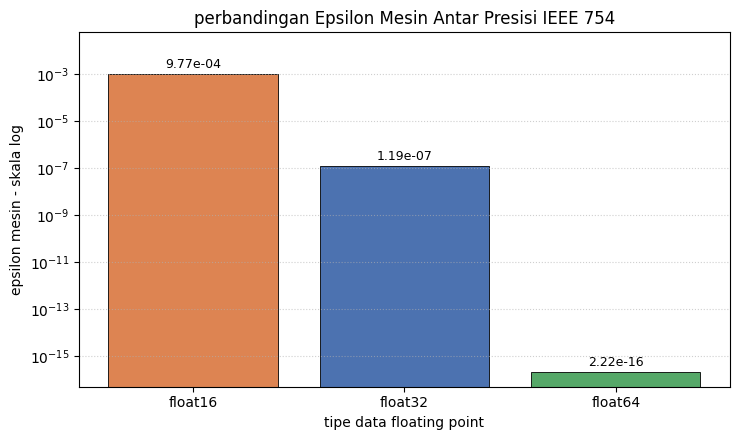

In [ ]:
# tabel ringkas dan grafik batang berskala logaritmik
import matplotlib.pyplot as plt

print(f"{'tipe':<10}{'total bit':>12}{'bit mantisa':>14}{'epsilon mesin':>20}{'digit desimal':>16}")
print("-" * 74)
baris = []
for nama, dt in [("float16", np.float16), ("float32", np.float32), ("float64", np.float64)]:
    info = np.finfo(dt)
    e = float(info.eps)
    baris.append((nama, e))
    print(f"{nama:<10}{info.bits:>12}{info.nmant:>14}{e:>20.6e}{info.precision:>16}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
nama_list = [r[0] for r in baris]
eps_list = [r[1] for r in baris]
bar = ax.bar(nama_list, eps_list, color=["#DD8452", "#4C72B0", "#55A868"],
             edgecolor="black", linewidth=0.6)
ax.set_yscale("log")
ax.set_ylabel("epsilon mesin - skala log")
ax.set_xlabel("tipe data floating point")
ax.set_title("perbandingan Epsilon Mesin Antar Presisi IEEE 754")
ax.grid(axis="y", which="both", linestyle=":", alpha=0.6)
for b, v in zip(bar, eps_list):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.8, f"{v:.2e}", ha="center", fontsize=9)
ax.set_ylim(top=max(eps_list) * 60)
plt.tight_layout()
plt.show()

### Jawaban HOTS 5

**Hasil.**

| Tipe | Total bit | Bit mantisa | Epsilon mesin | Digit desimal terjamin |
|---|---|---|---|---|
| float16 | 16 | 10 | 9.77e-04 | 3 |
| float32 | 32 | 23 | 1.19e-07 | 6 |
| float64 | 64 | 52 | 2.22e-16 | 15 |

Epsilon mesin np.float32 adalah 2^-23 = 1.1920929e-07, sedangkan float64 adalah 2^-52 = 2.220446e-16. Rasionya sekitar 5.4e8, jadi float64 kira-kira setengah miliar kali lebih halus daripada float32.

Tentang ketiga strategi: Strategi pembagian dengan tiga sengaja dipilih karena tidak sejajar dengan kisi biner. Karena itu ia tidak menghasilkan epsilon yang tepat, melainkan hanya menjepitnya di antara nilai terakhir yang masih terlihat dan nilai pertama yang sudah hilang. Ini justru pelajaran tersendiri: pola bagi dua pada modul berhasil tepat sasaran hanya karena kebetulan format floating point memang berbasis dua, sehingga tiap pembagian memindahkan hasil tepat satu langkah pada kisi. Strategi nextafter dan pembacaan bit mantisa keduanya menghasilkan nilai eksak dan saling bersesuaian sampai bit terakhir, yang mengonfirmasi bahwa epsilon memang semata-mata ditentukan oleh lebar mantisa.

makna kedua angka tsb

1. float32 hanya menjamin sekitar 6 sampai 7 digit desimal, sedangkan float64 sekitar 15 sampai 16 digit. Menampilkan hasil float32 dengan 10 digit di belakang koma adalah menipu diri sendiri, karena digit setelah yang ketujuh sudah tidak punya makna.
2. toleransi perbandingan harus mengikuti presisi yang dipakai. Menuntut galat 1e-10 dari perhitungan float32 mustahil dipenuhi, sebab batas bawahnya saja sudah 1.19e-7.
3. akumulasi galat pada float32 menjadi kasat mata jauh lebih cepat, persis seperti yang terlihat pada Tugas Praktikum nomor 2.
4. skala logaritmik wajib pada grafiknya, karena ketiga nilai terbentang 13 orde besaran; pada sumbu linier hanya batang float16 yang akan terlihat.

## HOTS 6 [C6 Mencipta]. Fungsi Penjumlahan Stabil

buat rata_rata_stabil(data) yang tahan terhadap galat pembulatan, lalu buktikan keunggulannya dengan data uji [1e16, 1.0, -1e16, 1.0]

In [ ]:
import math

def jumlah_beruntun(data):
    """baseline: penjumlahan beruntun polos, tanpa kompensasi apa pun."""
    total = 0.0
    for x in data:
        total += x
    return total

def kahan_sum(data):
    """kahan klasik: menyimpan sisa pembulatan tiap langkah lalu mengembalikannya."""
    total = 0.0
    kompensasi = 0.0
    for x in data:
        y = x - kompensasi
        t = total + y
        kompensasi = (t - total) - y
        total = t
    return total

def neumaier_sum(data):
    """kahan-Babuska-Neumaier: menambal kelemahan Kahan klasik.

    kahan klasik hanya menyelamatkan digit yang hilang ketika |x| lebih kecil
    daripada |total|. Neumaier memeriksa mana yang lebih besar lalu mengambil
    sisa dari sisi yang benar, sehingga tetap akurat ketika suku besar datang
    belakangan.
    """
    total = 0.0
    kompensasi = 0.0
    for x in data:
        t = total + x
        if abs(total) >= abs(x):
            kompensasi += (total - t) + x
        else:
            kompensasi += (x - t) + total
        total = t
    return total + kompensasi

def rata_rata_stabil(data, metode="neumaier"):
    """rata-rata yang tahan galat pembulatan.

    metode 'neumaier' : penjumlahan terkompensasi, tidak tergantung urutan  (disarankan)
    metode 'urut'     : jumlahkan dari magnitudo terkecil ke terbesar
    metode 'kahan'    : Kahan klasik, disertakan untuk perbandingan
    """
    n = len(data)
    if n == 0:
        raise ValueError("data kosong")
    if metode == "urut":
        total = jumlah_beruntun(sorted(data, key=abs))
    elif metode == "kahan":
        total = kahan_sum(data)
    else:
        total = neumaier_sum(data)
    return total / n

data = [1e16, 1.0, -1e16, 1.0]
eksak = 2.0 / 4          # jumlah sejatinya 2.0, rata-ratanya 0.5

print("data uji         :", data)
print("jumlah sejati    : 2.0")
print("rata-rata sejati :", eksak)
print("versi Python     :", __import__("sys").version.split()[0])
print()
print(f"{'metode':<40}{'rata-rata':>18}{'galat absolut':>18}")
print("-" * 76)
kandidat = [
    ("penjumlahan beruntun polos", jumlah_beruntun(data) / len(data)),
    ("sum() bawaan Python", sum(data) / len(data)),
    ("rata_rata_stabil urut", rata_rata_stabil(data, "urut")),
    ("rata_rata_stabil kahan klasik", rata_rata_stabil(data, "kahan")),
    ("rata_rata_stabil neumaier", rata_rata_stabil(data, "neumaier")),
    ("math.fsum (acuan eksak)", math.fsum(data) / len(data)),
]
for nama, v in kandidat:
    print(f"{nama:<40}{v:>18.10f}{abs(v - eksak):>18.10f}")

print()
print("jejak penjumlahan beruntun polos:")
t = 0.0
for x in data:
    sebelum = t
    t = t + x
    print(f"  {sebelum:>22.1f} + {x:>22.1f} = {t:>22.1f}")
print("  ulp di sekitar 1e16 =", math.ulp(1e16), "jadi 1e16 + 1.0 dibulatkan kembali ke 1e16")

data uji         : [1e+16, 1.0, -1e+16, 1.0]
jumlah sejati    : 2.0
rata-rata sejati : 0.5
versi Python     : 3.13.15

metode                                           rata-rata     galat absolut
----------------------------------------------------------------------------
penjumlahan beruntun polos                    0.2500000000      0.2500000000
sum() bawaan Python                           0.5000000000      0.0000000000
rata_rata_stabil urut                         0.5000000000      0.0000000000
rata_rata_stabil kahan klasik                 0.2500000000      0.2500000000
rata_rata_stabil neumaier                     0.5000000000      0.0000000000
math.fsum (acuan eksak)                       0.5000000000      0.0000000000

jejak penjumlahan beruntun polos:
                     0.0 +    10000000000000000.0 =    10000000000000000.0
     10000000000000000.0 +                    1.0 =    10000000000000000.0
     10000000000000000.0 +   -10000000000000000.0 =                    0.0
     

In [ ]:
# uji tambahan: 100.000 bilangan kecil yang mudah tenggelam oleh satu bilangan besar
import numpy as np

rng = np.random.default_rng(42)
kecil = rng.uniform(0.0, 1.0, 100_000).tolist()
data2 = [1e9] + kecil + [-1e9]
eksak2 = math.fsum(kecil) / len(data2)

print(f"{'metode':<40}{'rata-rata':>22}{'galat relatif':>18}")
print("-" * 80)
for nama, v in [
    ("penjumlahan beruntun polos", jumlah_beruntun(data2) / len(data2)),
    ("sum() bawaan Python", sum(data2) / len(data2)),
    ("rata_rata_stabil urut", rata_rata_stabil(data2, "urut")),
    ("rata_rata_stabil kahan klasik", rata_rata_stabil(data2, "kahan")),
    ("rata_rata_stabil neumaier", rata_rata_stabil(data2, "neumaier")),
    ("math.fsum (acuan eksak)", math.fsum(data2) / len(data2)),
]:
    print(f"{nama:<40}{v:>22.14f}{abs(v - eksak2) / abs(eksak2):>18.3e}")

print()
print("bukti bahwa urutan penjumlahan mengubah hasil:")
print("  jumlah_beruntun([1e16, 1.0, -1e16, 1.0]) =", jumlah_beruntun([1e16, 1.0, -1e16, 1.0]))
print("  jumlah_beruntun([1.0, 1.0, 1e16, -1e16]) =", jumlah_beruntun([1.0, 1.0, 1e16, -1e16]))
print()
print("mengapa Kahan klasik gagal pada data uji pertama:")
print("  pada langkah pertama total = 0.0 dan x = 1e16, jadi |x| jauh melebihi |total|")
print("  koreksi Kahan hanya menyelamatkan digit rendah dari y, bukan dari total")
print("  Neumaier memeriksa sisi mana yang lebih besar lalu mengambil sisa dari sisi yang benar")

metode                                               rata-rata     galat relatif
--------------------------------------------------------------------------------
penjumlahan beruntun polos                    0.50061492444668         1.658e-10
sum() bawaan Python                           0.50061492436367         0.000e+00
rata_rata_stabil urut                         0.50061492436323         8.760e-13
rata_rata_stabil kahan klasik                 0.50061492436323         8.760e-13
rata_rata_stabil neumaier                     0.50061492436367         0.000e+00
math.fsum (acuan eksak)                       0.50061492436367         0.000e+00

bukti bahwa urutan penjumlahan mengubah hasil:
  jumlah_beruntun([1e16, 1.0, -1e16, 1.0]) = 1.0
  jumlah_beruntun([1.0, 1.0, 1e16, -1e16]) = 2.0

mengapa Kahan klasik gagal pada data uji pertama:
  pada langkah pertama total = 0.0 dan x = 1e16, jadi |x| jauh melebihi |total|
  koreksi Kahan hanya menyelamatkan digit rendah dari y, bukan dari total
 

### Jawaban HOTS 6

Hasil pada data uji [1e16, 1.0, -1e16, 1.0]. Jumlah sejatinya 2.0 dan rata-rata sejatinya 0.5.

| Metode | Rata-rata | Galat absolut |
|---|---|---|
| penjumlahan beruntun polos | 0.25 | 0.25 |
| sum() bawaan Python | 0.5 | 0 |
| rata_rata_stabil dengan pengurutan | 0.5 | 0 |
| rata_rata_stabil dengan Kahan klasik | 0.25 | 0.25 |
| rata_rata_stabil dengan Neumaier | 0.5 | 0 |
| math.fsum (acuan eksak) | 0.5 | 0 |

mengapa urutan penjumlahan bisa mengubah hasil (bahasa awam)

Bayangkan sebuah papan skor digital yang hanya sanggup menampilkan 17 angka. Begitu skornya mencapai 10.000.000.000.000.000, papan itu tidak punya tempat lagi untuk satuan; kenaikan satu poin tidak mengubah apa pun yang tertera. Itulah yang terjadi pada 1e16 + 1.0: jarak antar bilangan float64 di sekitar 1e16 adalah 2.0, sehingga menambahkan 1.0 jatuh tepat di tengah dua bilangan yang bisa disimpan lalu dibulatkan ke genap, yaitu kembali ke 1e16. Angka 1 yang pertama hilang tanpa jejak. Setelah -1e16 dikurangkan, papan kembali ke nol dan barulah angka 1 yang kedua terhitung, sehingga totalnya 1.0 alih-alih 2.0.

Kalau urutannya dibalik, kedua angka 1 dijumlahkan dahulu selagi papan masih kosong sehingga keduanya terekam utuh, baru kemudian 1e16 datang dan pergi. Hasilnya benar. Jadi dalam aritmetika floating point penjumlahan tidak bersifat asosiatif: (a + b) + c belum tentu sama dengan a + (b + c), meskipun dalam matematika murni keduanya identik.

Temuan yang paling menarik: Kahan klasik pun bisa gagal. Ini bukan kesalahan implementasi, melainkan kelemahan algoritmanya yang memang sudah dikenal. Baris kompensasi = (t - total) - y hanya berhasil merekonstruksi digit yang terbuang ketika suku baru lebih kecil daripada akumulator. Pada data uji ini keadaannya justru terbalik: pada langkah pertama total masih 0.0 sementara x bernilai 1e16, sehingga yang kehilangan digit adalah total, bukan y, dan koreksinya mengambil sisa dari sisi yang salah. Akibatnya Kahan klasik ikut menghasilkan 1.0.

Perbaikannya adalah varian Kahan-Babuska-Neumaier, yang lebih dahulu memeriksa mana yang lebih besar antara |total| dan |x|, lalu mengambil sisa dari sisi yang benar, dan menambahkan akumulasi kompensasi satu kali di akhir. Dengan satu pemeriksaan tambahan itu, hasilnya menjadi benar untuk kedua arah, berapa pun urutan datanya. Inilah versi yang dipakai sebagai default pada rata_rata_stabil.

Catatan tentang sum() bawaan. Sejak Python 3.12, fungsi sum() untuk float sudah memakai penjumlahan Neumaier secara internal, sehingga ia juga menghasilkan 0.5 pada data uji ini. Karena itu sel di atas menyertakan jumlah_beruntun() secara eksplisit sebagai baseline, supaya perilaku penjumlahan polos yang sebenarnya tetap terlihat. Pada Python 3.11 ke bawah, sum() akan ikut menghasilkan 0.25.

Perbandingan ketiga strategi

- Pengurutan dari magnitudo terkecil murah dan intuitif, dan sangat efektif untuk data bertanda sama. Namun biayanya O(n log n), ia memerlukan seluruh data di memori sekaligus sehingga tidak cocok untuk aliran data, dan pada data bertanda campuran ia tidak menjamin apa-apa.
- Neumaier summation berjalan satu lintasan O(n), hanya memerlukan satu variabel tambahan, bekerja pada aliran data, dan akurasinya tidak bergantung pada urutan masukan. Ongkosnya sekitar lima operasi aritmetika per suku alih-alih satu. Untuk sebagian besar keperluan, inilah pilihan yang tepat.
- math.fsum() memberikan hasil yang terbukti eksak dengan menyimpan daftar jumlah parsial, sehingga menjadi acuan pembanding pada sel di atas. Ongkos memorinya lebih besar. Pada NumPy, np.sum() memakai pairwise summation yang jauh lebih baik daripada loop beruntun tetapi tetap bukan eksak.

## HOTS 7 [C5 Evaluasi]. Kapan Menambah Suku Menjadi Sia-sia

perluas eksperimen Task IV sampai n = 30. Apakah galat terus mengecil? Pada n berapa penambahan suku praktis tidak lagi bermanfaat, dan apa kaitannya dengan epsilon mesin?

In [ ]:
import math
import numpy as np

x = 1.0
eksak = math.exp(x)
eps = np.finfo(float).eps

print(f"{'n':>4} {'aproks':>20} {'Er':>14} {'Er / eps':>12} {'turun dari n-1 ?':>18}")
print("-" * 74)

er_sebelumnya = None
n_jenuh = None
for n in range(0, 31):
    aproks = taylor_exp(x, n)
    Er = abs(eksak - aproks) / eksak
    turun = "-" if er_sebelumnya is None else str(Er < er_sebelumnya)
    if er_sebelumnya is not None and Er >= er_sebelumnya and n_jenuh is None:
        n_jenuh = n - 1
    if n <= 20 or n % 2 == 0:
        print(f"{n:>4} {aproks:>20.17f} {Er:>14.3e} {Er / eps:>12.3f} {turun:>18}")
    er_sebelumnya = Er

print("-" * 74)
print("epsilon mesin      =", eps)
print("galat relatif pada n = 30 :", abs(eksak - taylor_exp(x, 30)) / eksak)
print("titik jenuh (galat berhenti turun) pada n =", n_jenuh)

   n               aproks             Er     Er / eps   turun dari n-1 ?
--------------------------------------------------------------------------
   0  1.00000000000000000      6.321e-01 2846817913193522.000                  -
   1  2.00000000000000000      2.642e-01 1190036199016548.000               True
   2  2.50000000000000000      8.030e-02 361645341928060.938               True
   3  2.66666666666666652      1.899e-02 85515056231898.828               True
   4  2.70833333333333304      3.660e-03 16482484807858.486               True
   5  2.71666666666666634      5.942e-04 2675970523050.419               True
   6  2.71805555555555545      8.324e-05 374884808915.373               True
   7  2.71825396825396837      1.025e-05 46158278324.337               True
   8  2.71827876984127004      1.125e-06 5067462000.365               True
   9  2.71828152557319225      1.114e-07 501815742.473               True
  10  2.71828180114638451      1.005e-08 45251116.611               True

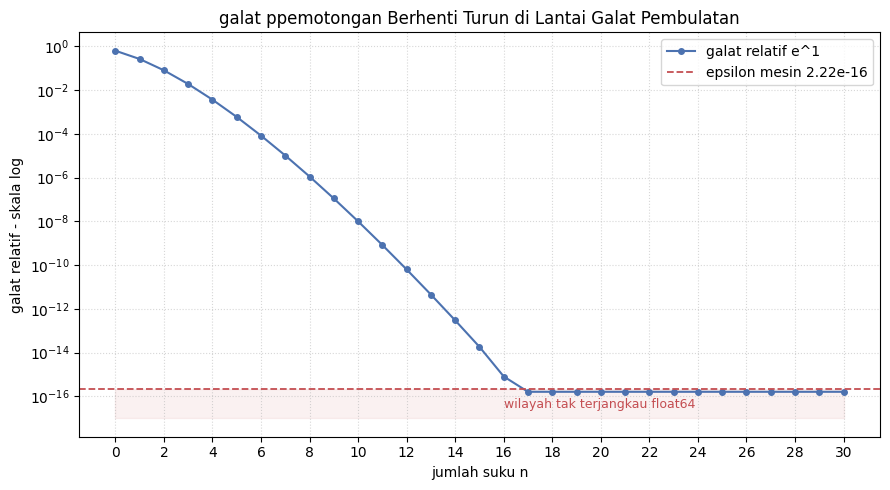

In [ ]:
# grafik: galat berhenti turun setelah menyentuh lantai epsilon mesin
import matplotlib.pyplot as plt

ns = list(range(0, 31))
er = [abs(math.exp(1.0) - taylor_exp(1.0, n)) / math.exp(1.0) for n in ns]
lantai = 1e-17

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(ns, [max(e, lantai) for e in er], marker="o", markersize=4,
            color="#4C72B0", label="galat relatif e^1")
ax.axhline(np.finfo(float).eps, color="#C44E52", linestyle="--", linewidth=1.3,
           label="epsilon mesin 2.22e-16")
ax.fill_between(ns, lantai, np.finfo(float).eps, color="#C44E52", alpha=0.08)
ax.text(16, 3e-17, "wilayah tak terjangkau float64", fontsize=9, color="#C44E52")
ax.set_xlabel("jumlah suku n")
ax.set_ylabel("galat relatif - skala log")
ax.set_title("galat ppemotongan Berhenti Turun di Lantai Galat Pembulatan")
ax.set_xticks(ns[::2])
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# implikasi ketika x diperbesar menjadi 10 dan 100
import math

print(f"{'x':>8} {'n':>5} {'aproks':>26} {'eksak':>26} {'Er':>12}")
print("-" * 82)
for xv in [1.0, 10.0, 100.0]:
    eksak = math.exp(xv)
    for n in [10, 20, 30]:
        aproks = taylor_exp(xv, n)
        Er = abs(eksak - aproks) / eksak
        print(f"{xv:>8} {n:>5} {aproks:>26.6e} {eksak:>26.6e} {Er:>12.3e}")
    print()

print("suku terbesar dalam deret (sumber galat pembulatan yang terakumulasi):")
for xv in [1.0, 10.0, 100.0]:
    suku = [xv ** k / math.factorial(k) for k in range(0, 31)]
    k_maks = max(range(len(suku)), key=lambda k: suku[k])
    print(f"  x = {xv:>6}: suku terbesar pada k = {k_maks:>2}, nilainya {suku[k_maks]:.3e}, "
          f"sedangkan e^x = {math.exp(xv):.3e}")

print()
print("kasus paling buruk, x negatif besar (cancellation antar suku bertanda ganti):")
xv = -20.0
print(f"  taylor_exp(-20, 30) = {taylor_exp(xv, 30):.6e}")
print(f"  math.exp(-20)       = {math.exp(xv):.6e}")
print(f"  1 / taylor_exp(20, 60) = {1 / taylor_exp(20.0, 60):.6e}  (reformulasi yang stabil)")

       x     n                     aproks                      eksak           Er
----------------------------------------------------------------------------------
     1.0    10               2.718282e+00               2.718282e+00    1.005e-08
     1.0    20               2.718282e+00               2.718282e+00    1.634e-16
     1.0    30               2.718282e+00               2.718282e+00    1.634e-16

    10.0    10               1.284231e+04               2.202647e+04    4.170e-01
    10.0    20               2.199148e+04               2.202647e+04    1.588e-03
    10.0    30               2.202646e+04               2.202647e+04    7.984e-08

   100.0    10               3.058238e+13               2.688117e+43    1.000e+00
   100.0    20               5.122365e+21               2.688117e+43    1.000e+00
   100.0    30               5.354165e+27               2.688117e+43    1.000e+00

suku terbesar dalam deret (sumber galat pembulatan yang terakumulasi):
  x =    1.0: suku terb

### Jawaban HOTS 7

Apakah galat terus mengecil? Tidak. Untuk x = 1, galat relatif turun tajam sampai sekitar n = 17, lalu mendarat pada level orde 1e-16 dan berhenti di situ. Setelah titik itu nilainya hanya berosilasi pada satu atau dua ulp, kadang naik kadang turun, tanpa kecenderungan menurun lagi.

Pada n berapa penambahan suku tidak lagi bermanfaat. Untuk x = 1, sekitar n = 17 sampai 18. Alasannya bisa diperkirakan sebelum program dijalankan: suku ke-n bernilai 1/n!, dan galat pemotongan kira-kira sebesar suku pertama yang dibuang. Menyamakan 1/(n+1)! dengan epsilon mesin 2.22e-16 memberi (n+1)! sekitar 4.5e15, dan karena 18! sekitar 6.4e15 sedangkan 17! sekitar 3.6e14, titik potongnya jatuh di sekitar n = 17. Setelah itu suku yang ditambahkan sudah lebih kecil daripada satu ulp dari total yang sudah terkumpul, sehingga penjumlahannya diserap pembulatan dan tidak mengubah hasil sama sekali.

Kaitannya dengan epsilon mesin. Galat total suatu perhitungan numerik adalah gabungan galat pemotongan dan galat pembulatan. Galat pemotongan menurun seiring bertambahnya n, sedangkan galat pembulatan yang terakumulasi justru naik perlahan seiring bertambahnya operasi aritmetika. Kurva gabungannya berbentuk huruf U yang dasarnya berada di sekitar epsilon mesin dikali akar dari jumlah operasi. Epsilon mesin berfungsi sebagai lantai: berapa pun banyak suku yang ditambahkan, galat relatif tidak akan pernah turun di bawah lantai itu tanpa berpindah ke presisi yang lebih tinggi, misalnya modul decimal atau mpmath. Menambah suku setelah menyentuh lantai hanya menambah waktu hitung dan sedikit menambah galat pembulatan, jadi murni kerugian.

Implikasi bila x diperbesar menjadi 10 atau 100

1. ttik jenuhnya bergeser jauh ke kanan. Suku ke-k bernilai x^k/k!, yang baru mulai mengecil setelah k melewati x. Untuk x = 100, suku terbesarnya muncul di sekitar k = 99 dengan nilai sekitar 1e42. Dengan hanya 30 suku, deretnya bahkan belum mencapai puncaknya, sehingga aproksimasinya masih salah total.
2. Lantai galatnya ikut naik. Suku terbesar untuk x = 10 bernilai sekitar 2.8e3 sedangkan e^10 hanya sekitar 2.2e4, jadi rasionya masih wajar. Untuk x = 100, suku terbesar sekitar 1e42 sementara e^100 sekitar 2.7e43, dan galat pembulatan yang melekat pada suku raksasa itu ikut terbawa ke hasil akhir. Galat relatif praktis tidak bisa lagi turun ke orde 1e-16 berapa pun n yang dipilih.
3. Untuk x negatif besar, keadaannya paling parah. Suku-sukunya berganti tanda dan saling meniadakan hampir sempurna, sehingga terjadi catastrophic cancellation antar suku yang besarnya jauh melebihi hasil akhir. Sel terakhir memperlihatkan taylor_exp(-20, 30) yang kacau, sedangkan reformulasi 1 / taylor_exp(20, 60) memberikan hasil yang benar.
4. Solusi yang dipakai puSTAKA nyata. Fungsi exp() pada pustaka matematika tidak pernah menjumlahkan deret Maclaurin secara langsung untuk argumen besar. Ia melakukan reduksi argumen terlebih dahulu, yaitu menulis x sebagai k dikali ln(2) ditambah r dengan |r| kecil, menghitung e^r lewat deret atau aproksimasi minimax yang pendek, lalu mengembalikan hasilnya dengan pergeseran eksponen 2^k. Dengan begitu deret selalu dievaluasi pada rentang sempit tempat konvergensinya cepat dan stabil.

Kesimpulan umum. Setiap metode numerik punya titik keseimbangan optimum antara galat pemotongan dan galat pembulatan. Mengejar akurasi melampaui titik itu tidak akan berhasil dan hanya memboroskan komputasi. Pola yang sama akan muncul kembali pada pemilihan ukuran langkah h untuk turunan numerik dan integrasi numerik di modul-modul berikutnya.

---
## Referensi

1. Burden, R. L., & Faires, J. D. (2011). *Numerical Analysis* (9th ed.). Brooks/Cole, Cengage Learning.
2. Chapra, S. C., & Canale, R. P. (2015). *Numerical Methods for Engineers* (7th ed.). McGraw-Hill Education.
3. Goldberg, D. (1991). What every computer scientist should know about floating-point arithmetic. *ACM Computing Surveys*, 23(1), 5-48.
4. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585(7825), 357-362.
5. Munir, R. (2021). *Metode Numerik* (Edisi Revisi). Informatika, Bandung.
6. Lions, J. L., et al. (1996). *ARIANE 5 Flight 501 Failure: Report by the Inquiry Board*. ESA/CNES, Paris.
7. IEEE. (2019). *IEEE Standard for Floating-Point Arithmetic* (IEEE 754-2019).